In [ ]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchdiffeq
import torch.nn.functional as F


In [4]:
# 把工程里的 research 加进 sys.path
import sys, os
PROJ_ROOT = r"C:\Users\ROG\Desktop\lab\fmtorch-Dian_fmresearch"  # 改成你的绝对路径
sys.path.insert(0, os.path.join(PROJ_ROOT, "research"))

# 验证一下
import os, sys
print("CWD =", os.getcwd())
print("Has fmtorch path?", os.path.join(PROJ_ROOT, "research") in sys.path)

import fmtorch  # 现在应能成功


CWD = c:\Users\ROG\Desktop\lab\fmtorch-Dian_fmresearch\research\fmtorch
Has fmtorch path? True


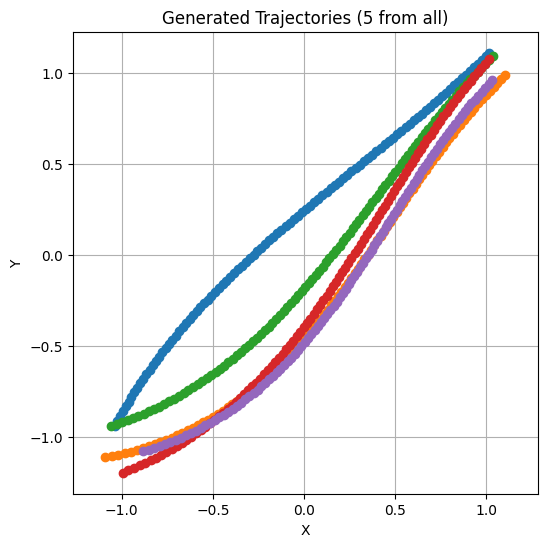

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

def sample_point_in_circle(center, radius):
    angle = np.random.uniform(0, 2 * np.pi)
    r = radius * np.sqrt(np.random.uniform(0, 1))
    return center + r * np.array([np.cos(angle), np.sin(angle)])

def generate_bezier_curve(P0, P1, P2, P3, num_points=100):
    t = np.linspace(0, 1, num_points).reshape(-1, 1)
    B_t = (1 - t)**3 * P0 + 3 * (1 - t)**2 * t * P1 + 3 * (1 - t) * t**2 * P2 + t**3 * P3
    return B_t  

# ---------------------------

baseline_start = np.array([-1, -1])
baseline_end   = np.array([ 1,  1])
radius = 0.2 

dominant_endpoint = "start"

if dominant_endpoint == "start":
    perturbation_scale_P1 = 0.7  
    perturbation_scale_P2 = 0.01 
elif dominant_endpoint == "end":
    perturbation_scale_P1 = 0.1  
    perturbation_scale_P2 = 0.3 
else:

    perturbation_scale_P1 = perturbation_scale_P2 = 0.2


num_trajectories = 8000 
trajectories = []

for i in range(num_trajectories):

    P0 = sample_point_in_circle(baseline_start, radius)
    P3 = sample_point_in_circle(baseline_end, radius)
    
    base_vector = P3 - P0
    perp_vector = np.array([-base_vector[1], base_vector[0]])
    perp_vector = perp_vector / (np.linalg.norm(perp_vector) + 1e-8)
  
    P1 = P0 + base_vector / 3.0
    P2 = P0 + 2 * base_vector / 3.0
    

    P1 = P1 + np.random.uniform(-perturbation_scale_P1, perturbation_scale_P1) * perp_vector
    P2 = P2 + np.random.uniform(-perturbation_scale_P2, perturbation_scale_P2) * perp_vector
    

    curve = generate_bezier_curve(P0, P1, P2, P3, num_points=100)

    curve = curve.T
    trajectories.append(curve)

trajectories = np.array(trajectories)

# ---------------------------

num_plots = 5
indices = np.random.choice(len(trajectories), size=num_plots, replace=False)

plt.figure(figsize=(6, 6))
for idx in indices:
    traj = trajectories[idx]
    plt.plot(traj[0], traj[1], marker='o', linestyle='-')
plt.title("Generated Trajectories (5 from all)")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True)
plt.show()

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# fmtorch imports
from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper
from fmtorch.models import UNetModelWrapper  


class TrajectoryDataset(Dataset):
    def __init__(self, trajectories):
        self.trajectories = trajectories
        print(trajectories.shape)

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = self.trajectories[idx]
        return torch.tensor(traj, dtype=torch.float32)
class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class FCFlattenUpsampler(nn.Module):
    def __init__(self, input_shape=(2, 100), output_shape=(1, 28, 28)):
        super().__init__()
        in_dim = input_shape[0] * input_shape[1]
        out_dim = output_shape[0] * output_shape[1] * output_shape[2]
        self.fc = nn.Sequential(
            nn.Linear(in_dim, 512),
            Mish(),
            nn.Linear(512, 512),
            Mish(),
            nn.Linear(512, out_dim)
        )
        self.norm = nn.LayerNorm(out_dim)
        self.output_shape = output_shape

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        x = self.norm(x)
        x = x.view(-1, *self.output_shape)
        return x

class FCDownsampler(nn.Module):
    def __init__(self, input_shape=(1, 28, 28), output_shape=(2, 100)):
        super().__init__()
        in_dim = input_shape[0] * input_shape[1] * input_shape[2]
        out_dim = output_shape[0] * output_shape[1]
        self.fc = nn.Sequential(
            nn.Linear(in_dim, 512),
            Mish(),
            nn.Linear(512, 512),
            Mish(),
            nn.Linear(512, out_dim)
        )
        self.output_shape = output_shape

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x.view(x.size(0), *self.output_shape)
    
class FlowMatchingModel(ModelWrapper):
    def __init__(self, upsampler, model, downsampler):
        super().__init__(model)
        self.upsampler = upsampler
        self.downsampler = downsampler
        
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):

        x_img = self.upsampler(x)
        
        dummy_label = torch.zeros((x.shape[0],), dtype=torch.long, device=x.device)
        
        v_img = self.model(t, x_img, dummy_label)
        
        v_traj = self.downsampler(v_img)
        
        return v_traj

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

upsampler = FCFlattenUpsampler().to(device)
downsampler = FCDownsampler().to(device)
unet_model = UNetModelWrapper(
    dim=(1, 28, 28),
    num_channels=64,
    num_res_blocks=2,
    num_classes=10,
    class_cond=True
).to(device)

fm_model = FlowMatchingModel(upsampler, unet_model, downsampler)

optimizer = torch.optim.Adam(
    list(unet_model.parameters()) +
    list(upsampler.parameters()) +
    list(downsampler.parameters()),
    lr=3e-4
)

path = AffinePath(scheduler=CondOTScheduler())

batch_size = 64
train_dataset = TrajectoryDataset(trajectories)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

n_epochs = 150
loss_history = []
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

for epoch in range(n_epochs):
    for batch_traj in train_loader:
        optimizer.zero_grad()
        
        x1_traj = batch_traj.to(device) 
        x0_traj = torch.randn_like(x1_traj)  
        
        t = torch.rand(x1_traj.shape[0]).to(device)
        
        path_sample = path.sample(t=t, x_0=x0_traj, x_1=x1_traj)
        
        vt_pred = fm_model(path_sample.x_t, path_sample.t)
        
        flow_loss = torch.mean((vt_pred - path_sample.dx_t) ** 2)
        
        x1_img = upsampler(x1_traj)
        recon_traj = downsampler(x1_img)
        recon_loss = torch.mean((recon_traj - x1_traj) ** 2)
        
        loss = flow_loss + 1.0 * recon_loss
        
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
    
    scheduler.step()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item():.6f}")

(8000, 2, 100)
Epoch 5/150, Loss: 0.153636
Epoch 10/150, Loss: 0.097171
Epoch 15/150, Loss: 0.095044
Epoch 20/150, Loss: 0.131352
Epoch 25/150, Loss: 0.109275
Epoch 30/150, Loss: 0.085993
Epoch 35/150, Loss: 0.090115
Epoch 40/150, Loss: 0.079737
Epoch 45/150, Loss: 0.081692
Epoch 50/150, Loss: 0.076380
Epoch 55/150, Loss: 0.082418
Epoch 60/150, Loss: 0.065493
Epoch 65/150, Loss: 0.065943
Epoch 70/150, Loss: 0.056114
Epoch 75/150, Loss: 0.082322
Epoch 80/150, Loss: 0.073263
Epoch 85/150, Loss: 0.068189
Epoch 90/150, Loss: 0.054035
Epoch 95/150, Loss: 0.062968
Epoch 100/150, Loss: 0.050105
Epoch 105/150, Loss: 0.047049
Epoch 110/150, Loss: 0.047245
Epoch 115/150, Loss: 0.047860
Epoch 120/150, Loss: 0.046403
Epoch 125/150, Loss: 0.050689
Epoch 130/150, Loss: 0.048674
Epoch 135/150, Loss: 0.044265
Epoch 140/150, Loss: 0.043938
Epoch 145/150, Loss: 0.041039
Epoch 150/150, Loss: 0.048040


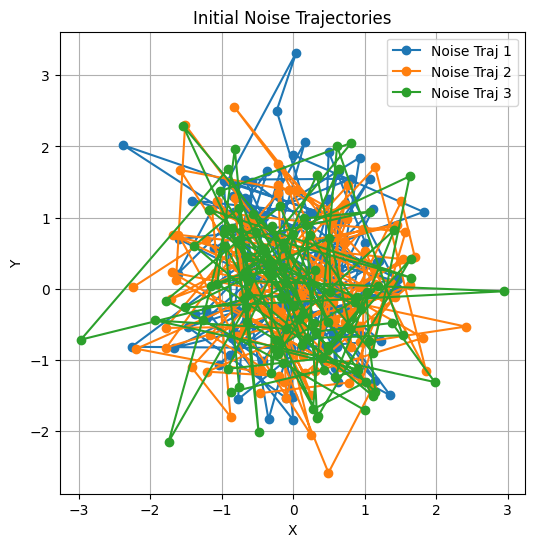

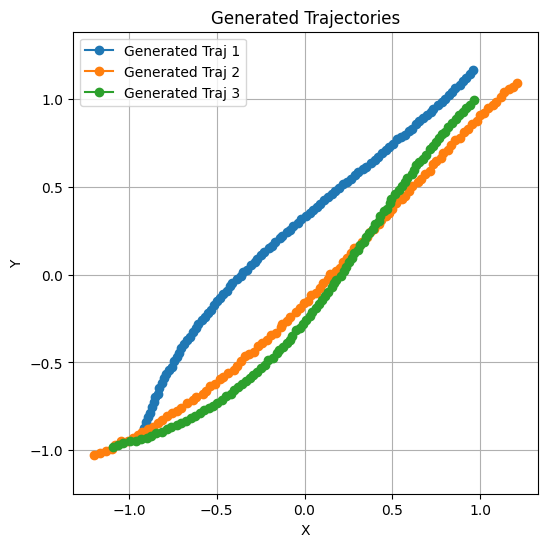

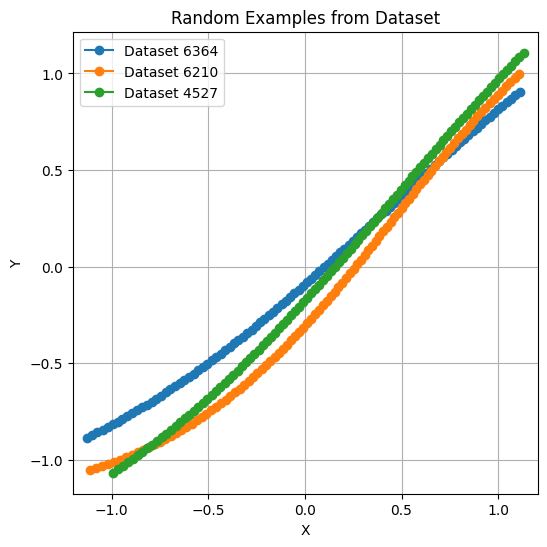

In [6]:
solver = ODESolver(velocity_model=fm_model)

with torch.no_grad():
    noise_trajs = torch.randn((3, 2, 100), device=device)

noise_trajs_np = noise_trajs.cpu().numpy()
plt.figure(figsize=(6, 6))
for i in range(3):
    plt.plot(noise_trajs_np[i, 0], noise_trajs_np[i, 1], 
             marker='o', label=f"Noise Traj {i+1}")
plt.title("Initial Noise Trajectories")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.show()

time_grid = torch.tensor([0.0, 1.0], device=device)

with torch.no_grad():
    generated_trajs = solver.sample(
        x_init=noise_trajs,
        time_grid=time_grid,
        method='dopri5',
        step_size=None,
        atol=1e-4,
        rtol=1e-4,
        return_intermediates=False
    )

generated_trajs_np = generated_trajs.cpu().numpy()
plt.figure(figsize=(6, 6))
for i in range(3):
    plt.plot(generated_trajs_np[i, 0], generated_trajs_np[i, 1], 
             marker='o', label=f"Generated Traj {i+1}")
plt.title("Generated Trajectories")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.show()

plt.figure(figsize=(6, 6))
rand_indices = np.random.choice(trajectories.shape[0], size=3, replace=False)
for idx in rand_indices:
    plt.plot(trajectories[idx, 0], trajectories[idx, 1], 
             marker='o', linestyle='-', label=f"Dataset {idx}")
plt.title("Random Examples from Dataset")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.show()